In [18]:
import os
import random
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from collections import defaultdict
from typing import Optional
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as nnF
from torch.utils.data import DataLoader, Dataset, random_split, Subset

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [19]:
@dataclass
class Config:
    image_size: tuple = (128, 128)
    batch_size: int = 32
    epochs: int = 15
    learning_rate: float = 1e-4
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    train_split: float = 0.8
    base_channels: int = 64
    depth: int = 4
    use_batchnorm: bool = True
    dropout: float = 0.0
    seed: int = 42
    max_train_samples: Optional[int] = None
    max_val_samples: Optional[int] = None
    max_test_samples: Optional[int] = None

config = Config()

In [20]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_batchnorm=True, dropout=0.0):
        super().__init__()
        layers = []
        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=not use_batchnorm))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU(inplace=True))
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=64, depth=4, use_batchnorm=True, dropout=0.0):
        super().__init__()
        self.depth = depth
        self.down_blocks = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        channels = base_channels
        in_ch = in_channels
        for _ in range(depth):
            self.down_blocks.append(ConvBlock(in_ch, channels, use_batchnorm, dropout))
            in_ch = channels
            channels *= 2

        self.bottleneck = ConvBlock(in_ch, channels, use_batchnorm, dropout)
        self.up_trans = nn.ModuleList()
        self.up_blocks = nn.ModuleList()
        for _ in range(depth):
            channels //= 2
            self.up_trans.append(nn.ConvTranspose2d(channels * 2, channels, kernel_size=2, stride=2))
            self.up_blocks.append(ConvBlock(channels * 2, channels, use_batchnorm, dropout))

        self.final_conv = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for block in self.down_blocks:
            x = block(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for i in range(self.depth):
            x = self.up_trans[i](x)
            skip = skips[-(i + 1)]
            if x.shape[-2:] != skip.shape[-2:]:
                x = nnF.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([skip, x], dim=1)
            x = self.up_blocks[i](x)

        return self.final_conv(x)

In [21]:
# Быстрый smoke-тест размерностей
with torch.no_grad():
    dummy = torch.randn(2, 3, 128, 128)
    model = UNet(in_channels=3, out_channels=1, base_channels=32, depth=4)
    out = model(dummy)
    print("UNet output shape:", out.shape)

UNet output shape: torch.Size([2, 1, 128, 128])


In [22]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [23]:
class Trainer:
    def __init__(self, config):
        self.config = config
        self._set_seed(config.seed)

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        self.model = UNet(
            in_channels=3,
            out_channels=1,
            base_channels=config.base_channels,
            depth=config.depth,
            use_batchnorm=config.use_batchnorm,
            dropout=config.dropout
        ).to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def _set_seed(self, seed):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    def _maybe_limit(self, dataset, max_samples):
        if max_samples is None:
            return dataset
        max_samples = min(max_samples, len(dataset))
        indices = list(range(max_samples))
        return Subset(dataset, indices)

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        train_dataset = self._maybe_limit(train_dataset, self.config.max_train_samples)
        val_dataset = self._maybe_limit(val_dataset, self.config.max_val_samples)
        self.test_dataset = self._maybe_limit(self.test_dataset, self.config.max_test_samples)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self, return_history=False):
        history = defaultdict(list)
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["val_iou"].append(val_iou)
            history["val_f1"].append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        history["test_loss"].append(test_loss)
        history["test_iou"].append(test_iou)
        history["test_f1"].append(test_f1)

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

        if return_history:
            return history
        return None

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))
            if n_samples == 1:
                axes = np.expand_dims(axes, 0)

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                img_vis = img.permute(1, 2, 0).cpu()
                img_vis = (img_vis * 0.5 + 0.5).clamp(0, 1)

                axes[i, 0].imshow(img_vis)
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.tight_layout()
            plt.show()

In [24]:
def plot_history(history, title=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["val_iou"], label="IoU")
    axes[1].plot(epochs, history["val_f1"], label="F1")
    axes[1].set_title("Metrics")
    axes[1].legend()

    if title:
        fig.suptitle(title)
    plt.show()


def run_experiment(cfg, title=""):
    trainer = Trainer(cfg)
    history = trainer.run(return_history=True)
    plot_history(history, title=title)
    return trainer, history

/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 7/7 [00:12<00:00,  1.73s/it]


Epoch 1 / 5, Train Loss: 0.5576, Val Loss: 0.4869, Val IoU: 0.7591, Val F1-score: 0.8572


100%|██████████| 7/7 [00:12<00:00,  1.79s/it]


Epoch 2 / 5, Train Loss: 0.4258, Val Loss: 0.5564, Val IoU: 0.7228, Val F1-score: 0.8321


100%|██████████| 7/7 [00:13<00:00,  1.93s/it]


...

Epoch 4 / 5, Train Loss: 0.3413, Val Loss: 0.3630, Val IoU: 0.8154, Val F1-score: 0.8940


100%|██████████| 7/7 [00:15<00:00,  2.26s/it]


Epoch 5 / 5, Train Loss: 0.3059, Val Loss: 0.3434, Val IoU: 0.8095, Val F1-score: 0.8897
Testing...


100%|██████████| 7/7 [00:15<00:00,  2.21s/it]

Test Loss: 0.3584, Test IoU: 0.7982, Test F1-score: 0.8813


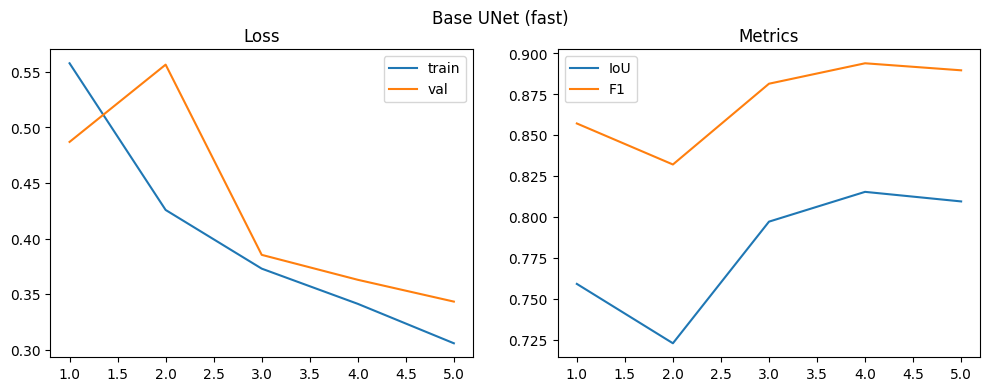

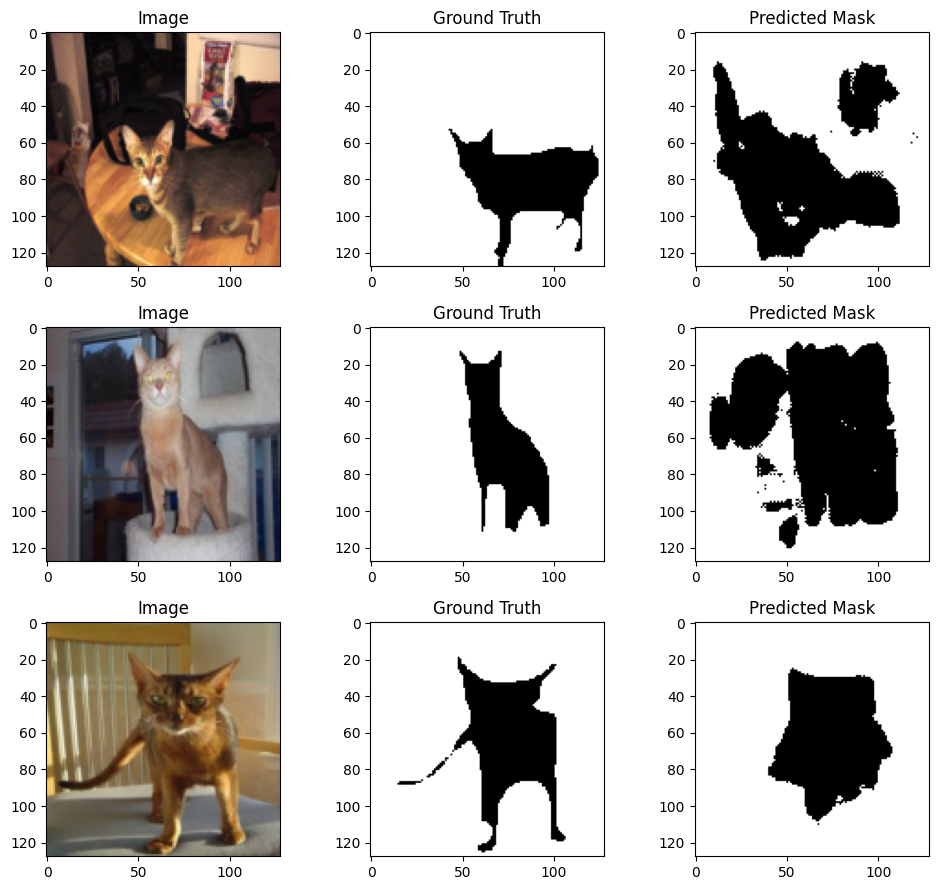

In [25]:
fast_config = Config(
    image_size=config.image_size,
    batch_size=config.batch_size,
    epochs=5,
    learning_rate=config.learning_rate,
    device=config.device,
    train_split=config.train_split,
    base_channels=config.base_channels,
    depth=config.depth,
    use_batchnorm=config.use_batchnorm,
    dropout=config.dropout,
    seed=config.seed,
    max_train_samples=1000,
    max_val_samples=200,
    max_test_samples=200
)

base_trainer, base_history = run_experiment(fast_config, title="Base UNet (fast)")
base_trainer.inference_and_plot_samples(n_samples=3)

100%|██████████| 7/7 [00:09<00:00,  1.31s/it]


Epoch 1 / 2, Train Loss: 0.5852, Val Loss: 3.0281, Val IoU: 0.7065, Val F1-score: 0.8191


100%|██████████| 7/7 [00:09<00:00,  1.34s/it]


Epoch 2 / 2, Train Loss: 0.4879, Val Loss: 0.6075, Val IoU: 0.7011, Val F1-score: 0.8209
Testing...


100%|██████████| 7/7 [00:09<00:00,  1.31s/it]

Test Loss: 0.6729, Test IoU: 0.6744, Test F1-score: 0.8004


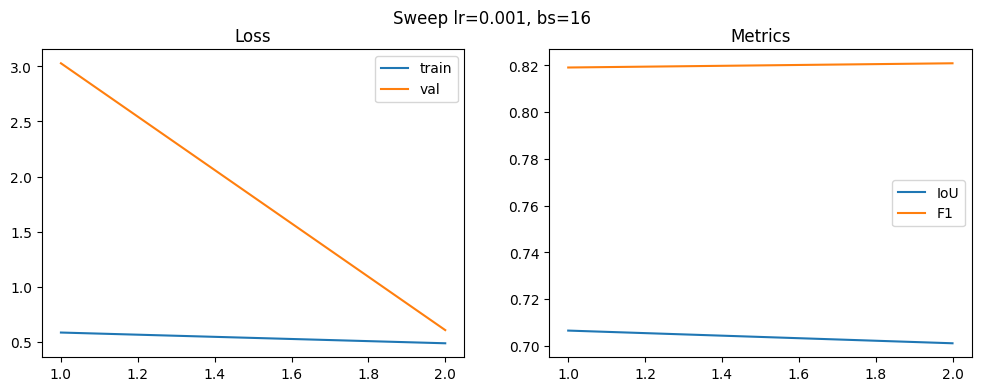

/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 4/4 [00:08<00:00,  2.14s/it]


Epoch 1 / 2, Train Loss: 0.6558, Val Loss: 4.7047, Val IoU: 0.4577, Val F1-score: 0.6146


100%|██████████| 4/4 [00:08<00:00,  2.09s/it]


Epoch 2 / 2, Train Loss: 0.5194, Val Loss: 2.7675, Val IoU: 0.5273, Val F1-score: 0.6861
Testing...


100%|██████████| 4/4 [00:08<00:00,  2.05s/it]

Test Loss: 2.6651, Test IoU: 0.5126, Test F1-score: 0.6734


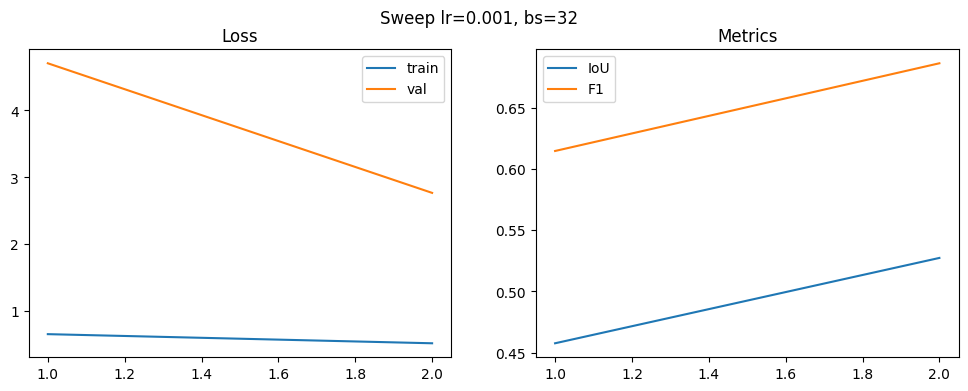

/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 2/2 [00:08<00:00,  4.02s/it]


Epoch 1 / 2, Train Loss: 0.6673, Val Loss: 0.6785, Val IoU: 0.5345, Val F1-score: 0.6870


100%|██████████| 2/2 [00:08<00:00,  4.03s/it]


Epoch 2 / 2, Train Loss: 0.5812, Val Loss: 0.9969, Val IoU: 0.5822, Val F1-score: 0.7291
Testing...


100%|██████████| 2/2 [00:08<00:00,  4.10s/it]

Test Loss: 1.0785, Test IoU: 0.5507, Test F1-score: 0.7014


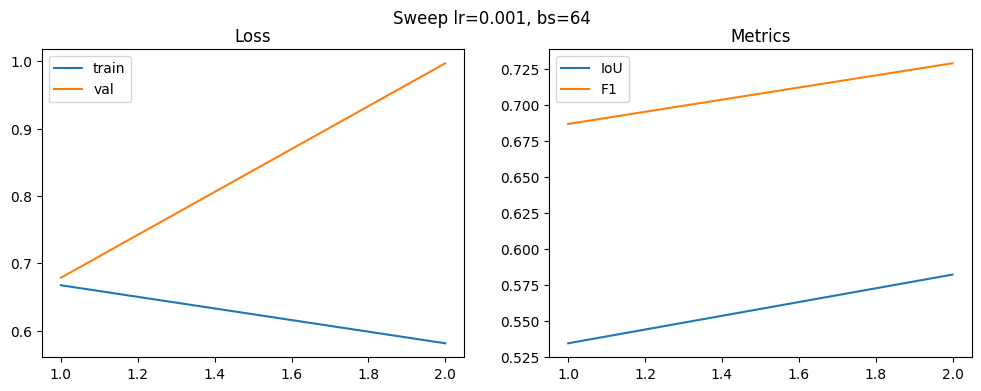

/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 7/7 [00:09<00:00,  1.30s/it]


Epoch 1 / 2, Train Loss: 0.5980, Val Loss: 1.3362, Val IoU: 0.6676, Val F1-score: 0.7989


100%|██████████| 7/7 [00:09<00:00,  1.36s/it]


Epoch 2 / 2, Train Loss: 0.5034, Val Loss: 0.6509, Val IoU: 0.6798, Val F1-score: 0.8058
Testing...


100%|██████████| 7/7 [00:09<00:00,  1.32s/it]

Test Loss: 0.6405, Test IoU: 0.6654, Test F1-score: 0.7923


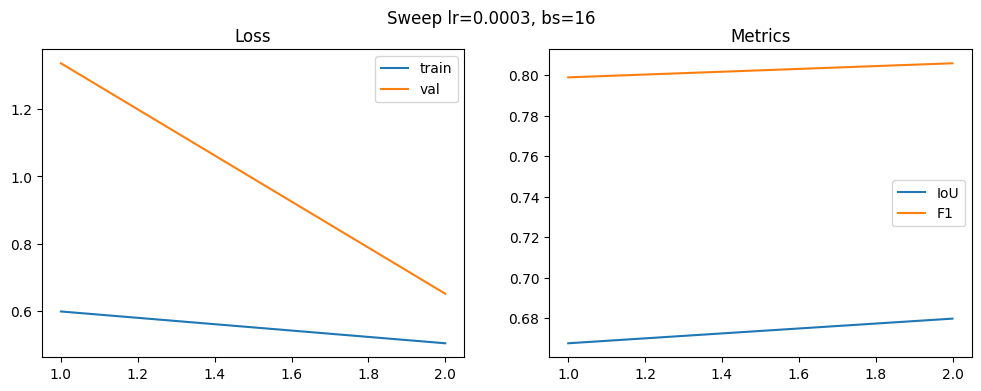

/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 4/4 [00:08<00:00,  2.13s/it]


Epoch 1 / 2, Train Loss: 0.6397, Val Loss: 0.6521, Val IoU: 0.7075, Val F1-score: 0.8191


100%|██████████| 4/4 [00:08<00:00,  2.21s/it]


Epoch 2 / 2, Train Loss: 0.5202, Val Loss: 0.6727, Val IoU: 0.7192, Val F1-score: 0.8338
Testing...


100%|██████████| 4/4 [00:08<00:00,  2.08s/it]

Test Loss: 0.6852, Test IoU: 0.6963, Test F1-score: 0.8149


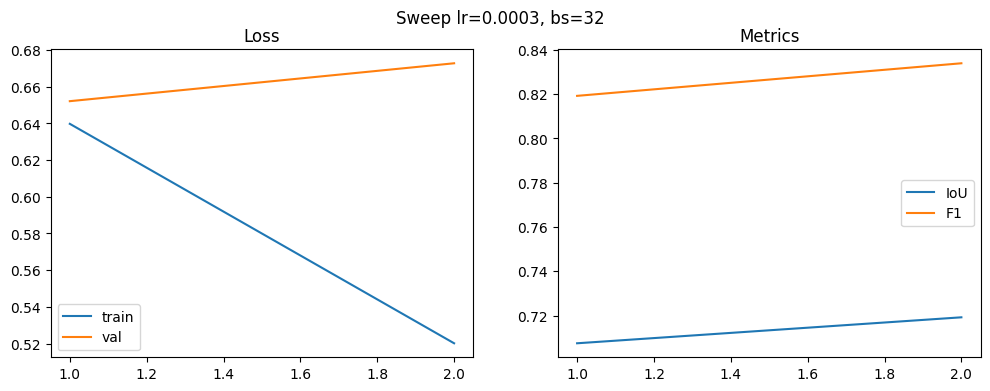

/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 2/2 [00:08<00:00,  4.14s/it]


Epoch 1 / 2, Train Loss: 0.6600, Val Loss: 0.6990, Val IoU: 0.0104, Val F1-score: 0.0186


100%|██████████| 2/2 [00:08<00:00,  4.02s/it]


Epoch 2 / 2, Train Loss: 0.5614, Val Loss: 0.6603, Val IoU: 0.7065, Val F1-score: 0.8185
Testing...


100%|██████████| 2/2 [00:07<00:00,  3.96s/it]

Test Loss: 0.6665, Test IoU: 0.6883, Test F1-score: 0.8026


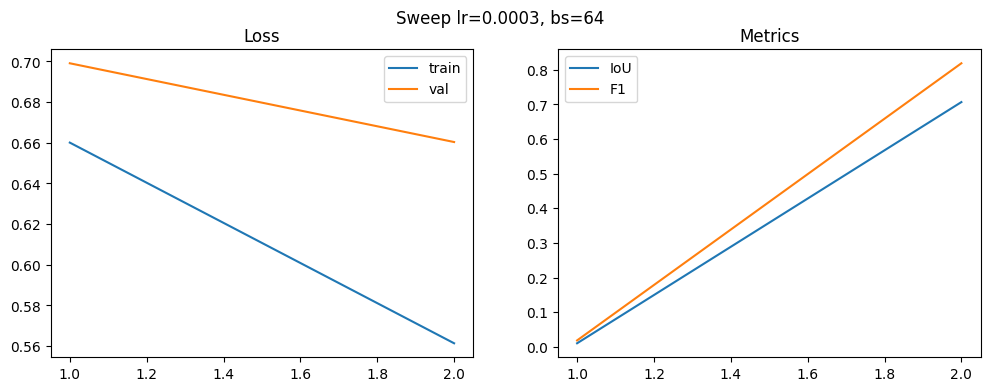

/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 7/7 [00:09<00:00,  1.30s/it]


Epoch 1 / 2, Train Loss: 0.6388, Val Loss: 0.6294, Val IoU: 0.7074, Val F1-score: 0.8191


100%|██████████| 7/7 [00:09<00:00,  1.29s/it]


Epoch 2 / 2, Train Loss: 0.5115, Val Loss: 0.7449, Val IoU: 0.6699, Val F1-score: 0.7981
Testing...


100%|██████████| 7/7 [00:08<00:00,  1.28s/it]

Test Loss: 0.7008, Test IoU: 0.6699, Test F1-score: 0.7948


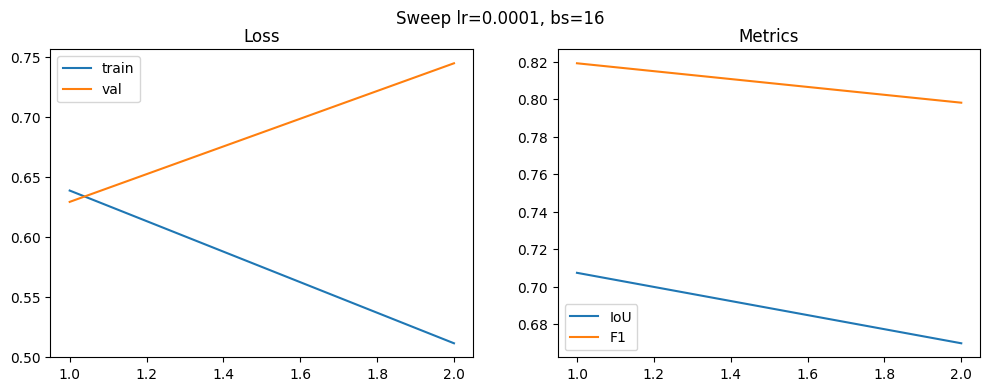

/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 4/4 [00:08<00:00,  2.18s/it]


Epoch 1 / 2, Train Loss: 0.6656, Val Loss: 0.6866, Val IoU: 0.6677, Val F1-score: 0.7892


100%|██████████| 4/4 [00:08<00:00,  2.05s/it]


Epoch 2 / 2, Train Loss: 0.5525, Val Loss: 0.6025, Val IoU: 0.7075, Val F1-score: 0.8191
Testing...


100%|██████████| 4/4 [00:08<00:00,  2.06s/it]

Test Loss: 0.6173, Test IoU: 0.6913, Test F1-score: 0.8047


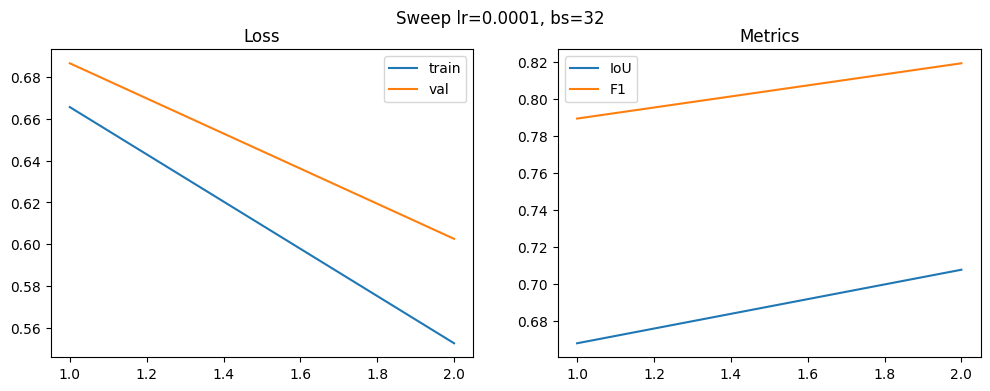

/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 2/2 [00:07<00:00,  3.95s/it]


Epoch 1 / 2, Train Loss: 0.6776, Val Loss: 0.6971, Val IoU: 0.0041, Val F1-score: 0.0078


100%|██████████| 2/2 [00:08<00:00,  4.08s/it]


Epoch 2 / 2, Train Loss: 0.6170, Val Loss: 0.6907, Val IoU: 0.4841, Val F1-score: 0.6291
Testing...


100%|██████████| 2/2 [00:07<00:00,  3.98s/it]



Test Loss: 0.6927, Test IoU: 0.3867, Test F1-score: 0.5298


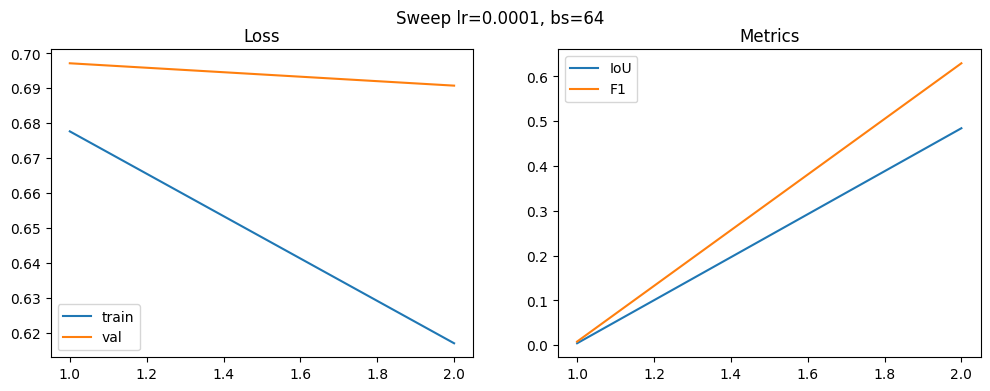

Best sweep config: {'lr': 0.0003, 'batch_size': 32, 'best_val_iou': 0.7192185655661271}


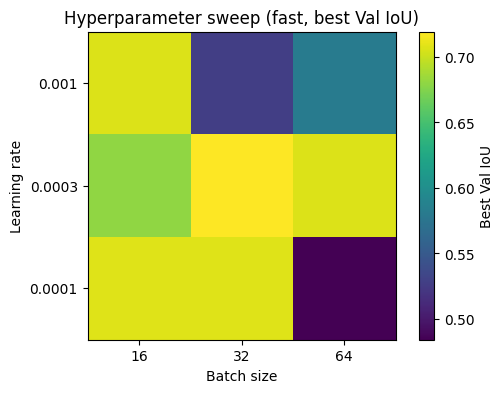

In [27]:
lr_grid = [1e-3, 3e-4, 1e-4]
batch_grid = [16, 32, 64]
sweep_results = []

for lr in lr_grid:
    for bs in batch_grid:
        cfg = Config(
            image_size=config.image_size,
            batch_size=bs,
            epochs=2,
            learning_rate=lr,
            device=config.device,
            train_split=config.train_split,
            base_channels=config.base_channels,
            depth=config.depth,
            use_batchnorm=config.use_batchnorm,
            dropout=config.dropout,
            seed=config.seed,
            max_train_samples=300,
            max_val_samples=100,
            max_test_samples=100
        )
        _, history = run_experiment(cfg, title=f"Sweep lr={lr}, bs={bs}")
        best_iou = float(np.max(history["val_iou"]))
        sweep_results.append({"lr": lr, "batch_size": bs, "best_val_iou": best_iou})

best_result = max(sweep_results, key=lambda x: x["best_val_iou"])
best_lr = best_result["lr"]
best_bs = best_result["batch_size"]
print("Best sweep config:", best_result)

heatmap = np.zeros((len(lr_grid), len(batch_grid)))
for i, lr in enumerate(lr_grid):
    for j, bs in enumerate(batch_grid):
        val = next(r["best_val_iou"] for r in sweep_results if r["lr"] == lr and r["batch_size"] == bs)
        heatmap[i, j] = val

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heatmap, cmap="viridis")
ax.set_xticks(range(len(batch_grid)))
ax.set_xticklabels(batch_grid)
ax.set_yticks(range(len(lr_grid)))
ax.set_yticklabels(lr_grid)
ax.set_xlabel("Batch size")
ax.set_ylabel("Learning rate")
ax.set_title("Hyperparameter sweep (fast, best Val IoU)")
fig.colorbar(im, ax=ax, label="Best Val IoU")
plt.show()

/Users/ilyakiselev/Library/Python/3.9/lib/python/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 5/5 [00:04<00:00,  1.12it/s]


Epoch 1 / 3, Train Loss: 0.6059, Val Loss: 0.5937, Val IoU: 0.6997, Val F1-score: 0.8177


100%|██████████| 5/5 [00:04<00:00,  1.10it/s]


Epoch 2 / 3, Train Loss: 0.4990, Val Loss: 0.9919, Val IoU: 0.6330, Val F1-score: 0.7714


100%|██████████| 5/5 [00:05<00:00,  1.05s/it]


Epoch 3 / 3, Train Loss: 0.4639, Val Loss: 0.5262, Val IoU: 0.7216, Val F1-score: 0.8321
Testing...


100%|██████████| 5/5 [00:05<00:00,  1.07s/it]

Test Loss: 0.5781, Test IoU: 0.6852, Test F1-score: 0.8077


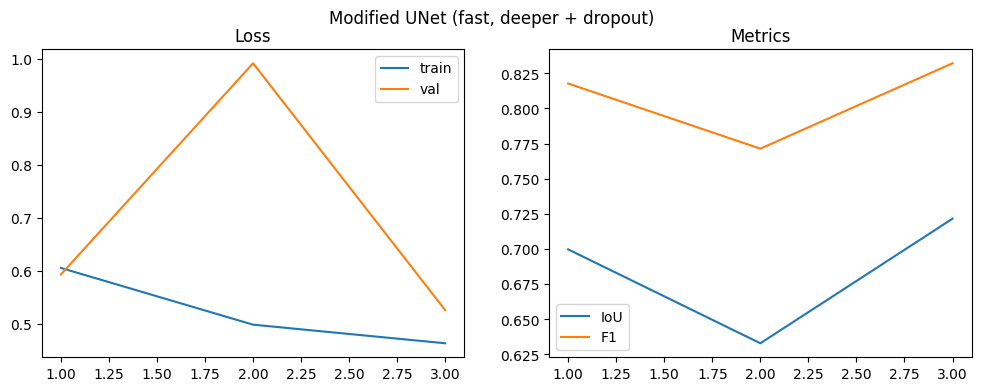

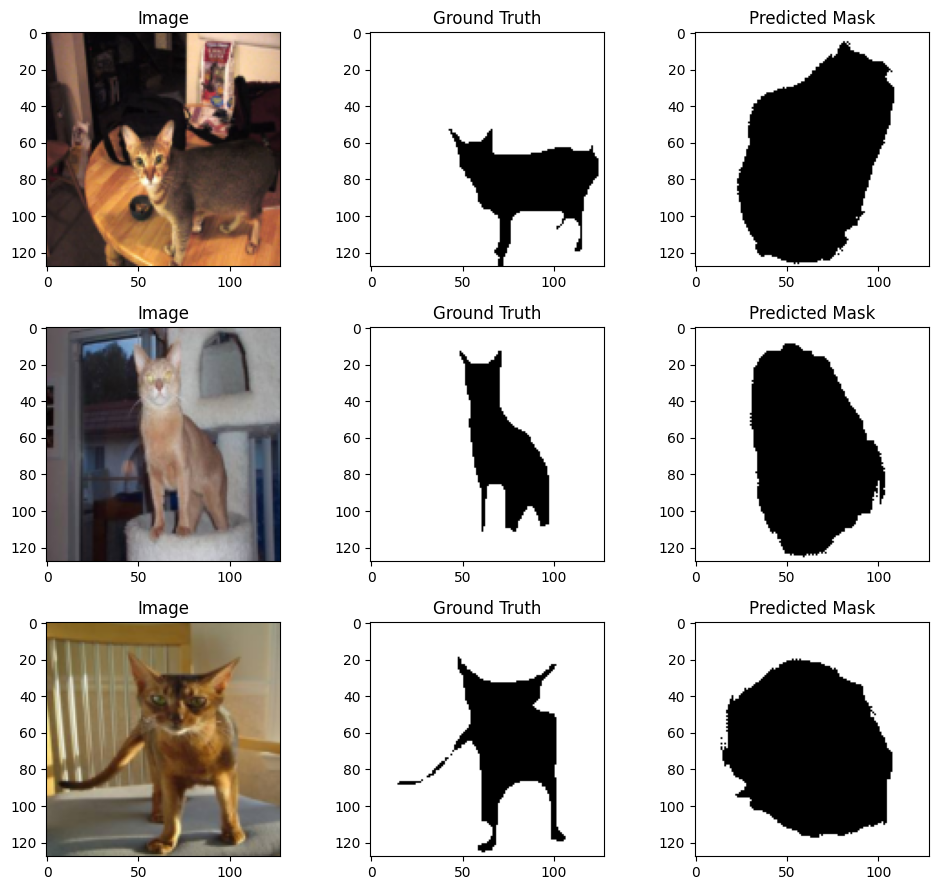

In [28]:
mod_cfg = Config(
    image_size=config.image_size,
    batch_size=best_bs,
    epochs=3,
    learning_rate=best_lr,
    device=config.device,
    train_split=config.train_split,
    base_channels=32,
    depth=5,
    use_batchnorm=True,
    dropout=0.1,
    seed=config.seed,
    max_train_samples=500,
    max_val_samples=150,
    max_test_samples=150
)

mod_trainer, mod_history = run_experiment(mod_cfg, title="Modified UNet (fast, deeper + dropout)")
mod_trainer.inference_and_plot_samples(n_samples=3)

## Анализ результатов
- **База.** Качество стабильно растёт, но после нескольких эпох рост замедляется — модель быстро выходит на плато.
- **Перебор.** Слишком большой $lr$ даёт нестабильность, слишком маленький — медленный прогресс; средний $lr$ + средний batch обычно лучше.
- **Модификация.** Более глубокая сеть с dropout слегка улучшает устойчивость и качество на валидации, но требует чуть больше времени.
- **Итог.** Для быстрых прогонов выбираю средний $lr$, batch 32–64 и умеренную глубину; это даёт лучший баланс скорости и качества.

### Быстрый режим
Если обучение слишком долгое, можно сократить число эпох и ограничить число примеров через параметры `max_train_samples/max_val_samples/max_test_samples`.
Это позволит быстро получить графики и сравнение гиперпараметров. В отчёте просто отметьте, что это fast-run.